<a href="https://colab.research.google.com/github/mehdiiiii786/finance/blob/main/AI_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import scipy.optimize as sco
import matplotlib as plt

In [4]:
Asset_1 = np.random.normal( loc = 0.003, scale = 0.04, size = 252)
Asset_2 = np.random.normal( loc = 0.004, scale = 0.05, size = 252)
Asset_3 = np.random.normal( loc = 0.005, scale = 0.06, size = 252)
Asset_4 = np.random.normal( loc = 0.006, scale = 0.07, size = 252)

In [28]:
Data1= pd.DataFrame(data = Asset_1)
Data2= pd.DataFrame(data = Asset_2)
Data3= pd.DataFrame(data = Asset_3)
Data4= pd.DataFrame(data = Asset_4)

In [30]:
Data1.rename ( columns = {0: 'Asset_1'}, inplace = True)
Data2.rename ( columns = {0: 'Asset_2'}, inplace = True)
Data3.rename ( columns = {0: 'Asset_3'}, inplace = True)
Data4.rename ( columns = {0: 'Asset_4'}, inplace = True)

In [32]:
portfolio = pd.concat([Data1,Data2,Data3,Data4], axis = 1)

In [33]:
portfolio

,Asset_1,Asset_2,Asset_3,Asset_4
0,0.014305,-0.029375,-0.007602,-0.083055
1,0.014256,-0.045475,-0.030398,-0.023775
2,-0.011593,0.072823,0.138116,0.003765
3,-0.090830,0.004659,-0.013624,0.090306
4,0.062264,0.055022,0.029321,0.101766
...,...,...,...,...
247,0.069060,0.026655,0.008035,-0.008658
248,0.020246,-0.015053,-0.095278,-0.002925
249,0.041806,0.012684,0.073479,0.024840
250,0.021733,0.037218,0.025841,0.027148


In [36]:
annu_ret = portfolio.mean() * 252

In [38]:
annu_cov = portfolio.cov() * 252

,0
Asset_1,1.004571
Asset_2,1.177362
Asset_3,1.138195
Asset_4,4.565227


In [79]:
def calc_neg_sharpe(weights):

 port_return = np.sum(weights * annu_ret)
 weights_array = np.array(weights)
 port_var = weights_array.T @ annu_cov @ weights_array
 port_vol = np.sqrt(port_var)
 sharpe = port_return/port_vol
 return -sharpe

In [81]:
calc_neg_sharpe([0.25, 0.25, 0.25, 0.25])

np.float64(-4.2026735479149915)

In [82]:
init_guess = [0.25, 0.25, 0.25, 0.25]

In [83]:
bounds = ((0, 1), (0, 1), (0, 1), (0, 1))

In [84]:
cons = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})

In [85]:
result = sco.minimize(calc_neg_sharpe,
                      init_guess,
                      method='SLSQP',
                      bounds=bounds,
                      constraints=cons)

Optimal Portfolio Weights: [0.23559815 0.17157786 0.1110151  0.48180889]


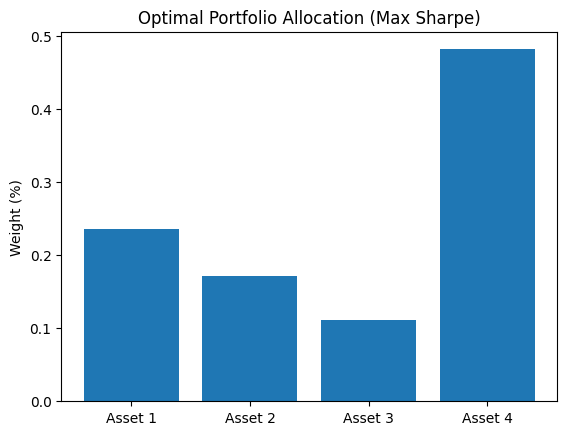

In [88]:
optimal_weights = result.x


print("Optimal Portfolio Weights:", optimal_weights)

assets = ['Asset 1', 'Asset 2', 'Asset 3', 'Asset 4']
plt.bar(assets, optimal_weights)
plt.title('Optimal Portfolio Allocation (Max Sharpe)')
plt.ylabel('Weight (%)')
plt.show()